In [1]:
from tensorflow import keras

In [2]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

4422102/4422102 [==============================] - 1s 0us/step


In [3]:
print(train_input.shape, train_target.shape)
print(test_input.shape, test_target.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


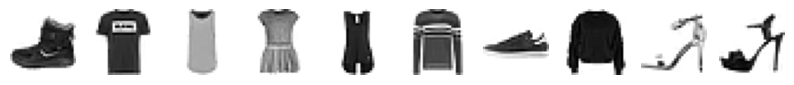

In [4]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray_r')
  axs[i].axis('off')
plt.show()

In [5]:
print([train_target[i] for i in range(10)])


[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [11]:
import numpy as np
print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [12]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1,28*28)

In [13]:
print(train_scaled.shape)

(60000, 784)


In [ ]:
from sklearn.linear_model import SGDClassifier
sc=SGDClassifier(loss='log', max_iter=5, random_state=42)

In [ ]:
from sklearn.model_selection import cross_validate
scores = cross_validate(sc, train_scaled, train_target, n_jobs=1)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_mod

In [ ]:
print(np.mean(scores['test_score']))

0.8196000000000001


In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
train_scaled, train_target, test_size=0.2, random_state=42)
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


In [ ]:
dense = keras.layers.Dense(10, activation='softmax', input_shape=(784,))
model = keras.Sequential(dense)

In [ ]:
model.compile(optimizer='rnsprop', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [ ]:
model.fit(train_scaled, train_target, epochs=5)
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.6083 - accuracy: 0.7933
Epoch 2/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.4745 - accuracy: 0.8390
Epoch 3/5
1500/1500 [==============================] - 3s 2ms/step - loss: 0.4506 - accuracy: 0.8471
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.4382 - accuracy: 0.8514
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.4475 - accuracy: 0.8461


[0.4475405812263489, 0.8460833430290222]

In [ ]:
dense1 = keras.layers.Dense(100, activation='sigmoid', input_shape=(784,))
dense2 = keras.layers.Dense(10, activation='softmax')
model = keras.Sequential([dense1, dense2])
model.summary()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 100)               78500     
                                                                 
 dense_29 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, activation='sigmoid', input_shape=(784,),
                       name='hidden'),
    keras.layers.Dense(10, activation='softmax', name='output')
], name='패션 MNIST 모델')

In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(keras.layers.Dense(10, activation='softmax'))

In [ ]:
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.5695 - accuracy: 0.8081
Epoch 2/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.4108 - accuracy: 0.8517
Epoch 3/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3758 - accuracy: 0.8626
Epoch 4/5
1500/1500 [==============================] - 4s 3ms/step - loss: 0.3526 - accuracy: 0.8709
Epoch 5/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3357 - accuracy: 0.8784


In [7]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28,28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 100)               78500     
                                                                 
 dense_1 (Dense)             (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [41]:
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
train_scaled, train_target, test_size=0.2, random_state=42)
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy', metrics='accuracy')
sgd = keras.optimizers.SGD()
model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics='accuracy')
sgd = keras.optimizers.SGD(learning_rate=0.1)
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)
adagrad = keras.optimizers.Adagrad()
model.compile(optimizer=adagrad, loss='sparse_categorical_crossentropy', metrics='accuracy')
rmsprop = keras.optimizers.RMSprop()
model.compile(optimizer=rmsprop, loss='sparse_categorical_crossentropy', metrics='accuracy')
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28, 28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
model.fit(train_scaled, train_target, epochs=5)
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 8s 5ms/step - loss: 0.5257 - accuracy: 0.8173
Epoch 2/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3993 - accuracy: 0.8580
Epoch 3/5
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3560 - accuracy: 0.8697
Epoch 4/5
1500/1500 [==============================] - 6s 4ms/step - loss: 0.3272 - accuracy: 0.8792
Epoch 5/5
375/375 [==============================] - 1s 2ms/step - loss: 0.3382 - accuracy: 0.8764


[0.3381762206554413, 0.8764166831970215]

In [43]:
model.compile(optimizer='sgd', loss='sparse_categorical_crossentropy',
              metrics='accuracy')

#sgd = keras.optimizers.SGD()
#model.compile(optimizer=sgd, loss='sparse_categorical_crossentropy', metrics='accuracy')

sgd = keras.optimizers.SGD(learning_rate = 0.1)
sgd = keras.optimizers.SGD(momentum=0.9, nesterov=True)

model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(28,28)))
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics='accuracy')

In [45]:
model.fit(train_scaled, train_target, epochs=5)
model.evaluate(val_scaled, val_target)

Epoch 1/5
1500/1500 [==============================] - 7s 4ms/step - loss: 0.2895 - accuracy: 0.8935
Epoch 2/5
1500/1500 [==============================] - 5s 4ms/step - loss: 0.2783 - accuracy: 0.8973
Epoch 3/5
1500/1500 [==============================] - 12s 8ms/step - loss: 0.2659 - accuracy: 0.9015
Epoch 4/5
1500/1500 [==============================] - 9s 6ms/step - loss: 0.2562 - accuracy: 0.9048
Epoch 5/5
375/375 [==============================] - 2s 6ms/step - loss: 0.3262 - accuracy: 0.8845


[0.3261593282222748, 0.8845000267028809]

dict_keys(['loss', 'accuracy'])


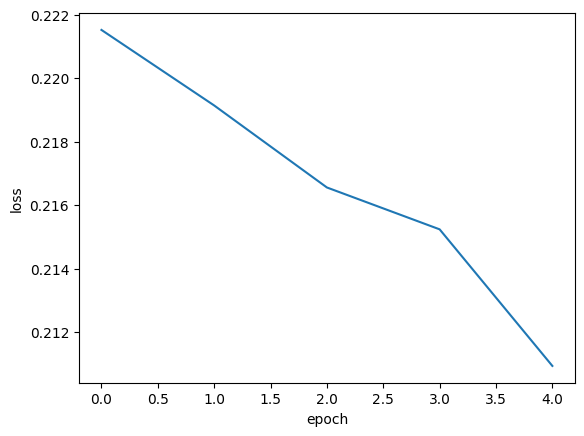

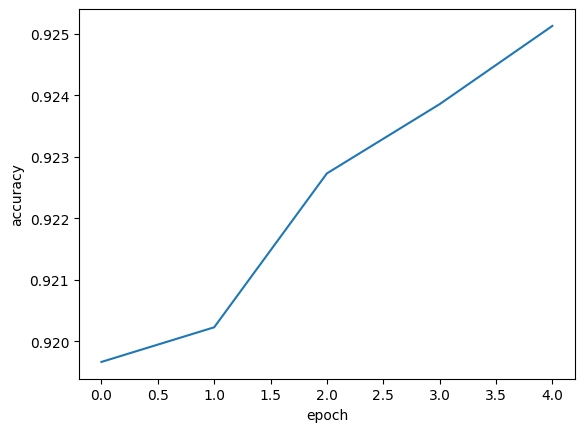

In [47]:
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)
print(history.history.keys())

import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.savefig('7_3-01', dpi=300)
plt.show()

plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.savefig('7_3-02', dpi=300)
plt.show()

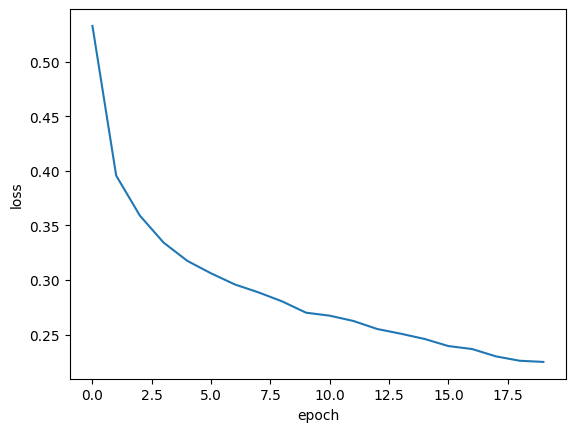

In [55]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28, 28)))
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics='accuracy')

history = model.fit(train_scaled, train_target, epochs=20, verbose=0)
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

Model: "sequential_23"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_17 (Flatten)        (None, 784)               0         
                                                                 
 dense_36 (Dense)            (None, 100)               78500     
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_37 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


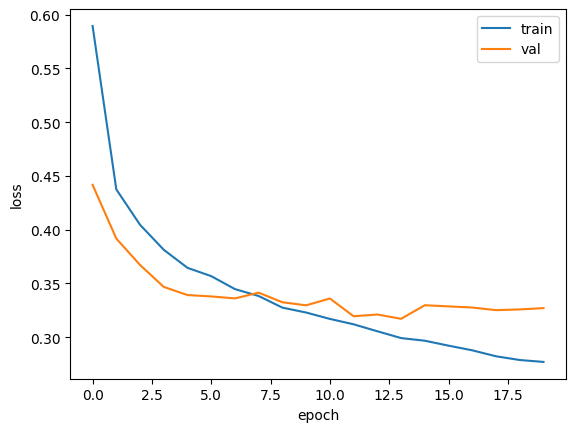

In [58]:
model = model_fn(keras.layers.Dropout(0.3))
model.summary()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics='accuracy')
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

실습 성능비교 ?

In [22]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
cancer = load_breast_cancer()
x = cancer.data
y = cancer.target
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import SGDClassifier
sgdc = SGDClassifier(loss='log', max_iter=10, random_state=1980)
sgdc.fit(x_train,y_train)
sgdc.score(x_test, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.9298245614035088

In [ ]:
from tensorflow import keras
dense_out = keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))
model_wbc = keras.Sequential(dense_out)
model_wbc.compile(loss='binary_crossentropy', metrics='accuracy')
model_wbc.fit(x_train, y_train, epochs=500)
model_wbc.evaluate(x_test, y_test)

In [25]:
from sklearn.linear_model import SGDClassifier
import numpy as np
x_train_scaled=(x_train-np.mean(x_train))/np.std(x_train)
x_test_scaled=(x_test-np.mean(x_train))/np.std(x_train)
sgdc = SGDClassifier(loss='log', max_iter=10, random_state=1980)
sgdc.fit(x_train_scaled,y_train)
sgdc.score(x_test_scaled, y_test)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.9298245614035088

In [ ]:
from tensorflow import keras
x_train_scaled=(x_train-np.mean(x_train))/np.std(x_train)
x_test_scaled=(x_test-np.mean(x_train))/np.std(x_train)
dense_out = keras.layers.Dense(1, activation='sigmoid', input_shape=(30,))
model = keras.Sequential(dense_out)
model.compile(loss='binary_crossentropy', metrics='accuracy')
model.fit(x_train, y_train, epochs=500)
model.evaluate(x_test, y_test)

In [27]:
dense1 = keras.layers.Dense(100, activation = 'sigmoid', input_shape=(784,))
dense2 = keras.layers.Dense(10, activation='softmax')

model = keras.Sequential([dense1,dense2])
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 100)               78500     
                                                                 
 dense_11 (Dense)            (None, 10)                1010      
                                                                 
Total params: 79510 (310.59 KB)
Trainable params: 79510 (310.59 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


실습 모델구축

In [61]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print(cancer.data.shape, cancer.target.shape)
print(cancer.data[:3])
print(cancer.target[:3])

(569, 30) (569,)
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]]
[0 0 0]


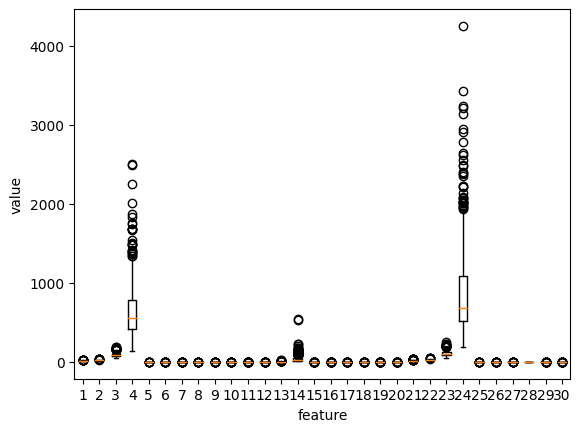

In [62]:
import matplotlib.pyplot as plot
plt.boxplot(cancer.data)
plt.xlabel('feature')
plt.ylabel('value')
plt.show()

In [64]:
cancer.feature_names[[3,12,23]]

array(['mean area', 'perimeter error', 'worst area'], dtype='<U23')

In [65]:
import numpy as np
print(np.unique(cancer.target, return_counts=True))

(array([0, 1]), array([212, 357]))


In [66]:
x = cancer.data
y = cancer.target
print(x)
print(y)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 

In [67]:
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)

(455, 30) (114, 30)


In [68]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([170, 285]))


In [69]:
import tensorflow as tf
from tensorflow import keras
dense = keras.layers.Dense(10, activation='softmax', input_shape=(30,))
model = keras.Sequential(dense)